# Sumativa 3 – Fase 4: Modelado Predictivo Integrado
## MCDI501: Estadística Computacional para la Toma de Decisiones
### Proyecto: Bank Marketing – Predicción de Suscripción a Depósito a Plazo

| Campo | Detalle |
|---|---|
| **Integrantes** | José Miguel Serrano · Jesús Fernández Urbaneja · Osvaldo Rodrigo Moncada Peralta · Evelyn Andrea Andrade Cárdenas |
| **Docente** | Jean Paul Maidana González |
| **Repositorio** | https://github.com/leofer23/formativa1-bank-marketing |
| **Fecha** | 25/06/2026 |

---
## Progresión metodológica S1 → S2 → S3

| Fase | Evaluación | Aporte a esta fase |
|---|---|---|
| S1 | Sumativa Fase 2 | EDA, IC Wilson, pruebas de hipótesis: poutcome (V=0.293), contact (V=0.139), balance (Mann-Whitney, d=0.061) |
| S2 | Sumativa Fase 3 | Bootstrap (1000 remuestras): poutcome estable IC=[0.247,0.338]; correlación pdays-previous robusta (r=0.578); Monte Carlo: priorizar poutcome=success genera +276 suscriptores/500 llamadas |
| S3 | **Esta evaluación** | Imputación por regresión, regresión logística (3 modelos), bootstrap de coeficientes, diagnóstico VIF, comparación de estrategias de imputación |

---
## Índice
1. [Carga de datos y resultados S1/S2](#s1)
2. [Parte 1: Imputación de datos faltantes](#p1)
3. [Parte 2: Regresión logística](#p2)
4. [Parte 3: Comparación del impacto de imputación](#p3)
5. [Conclusiones integradas S1→S2→S3](#conc)


In [1]:
# Instalacion de dependencias (ejecutar solo una vez, luego reiniciar kernel)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy scikit-learn --quiet
print("Librerias instaladas OK")


Librerias instaladas OK



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\jm123\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## 1. Carga de datos y resultados S1/S2 <a id='s1'></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, accuracy_score,
    recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
    'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})
COLOR_SI='#1a6ea8'; COLOR_NO='#c0392b'; COLOR_NEU='#2c3e50'
print('Librerias cargadas OK')

Librerias cargadas OK


In [3]:
# Carga del dataset y resultados validados de S2
df = pd.read_csv('../S1/bank.csv', sep=';')
res_s2 = pd.read_csv('../S2/resultados_validados.csv')
print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Resultados S2 cargados: {len(res_s2)} registros')
print()
print('=== Resultados clave de S2 usados en S3 ===')
key_s2 = res_s2[res_s2['parametro'].isin(['cramer_v_poutcome','cohen_d_duration',
    'mediana_balance','mediana_duration','pdays-previous'])]
print(key_s2[['parametro','estimacion','ic_low','ic_high','estabilidad']].to_string(index=False))


Dataset: 4,521 filas x 17 columnas
Resultados S2 cargados: 18 registros

=== Resultados clave de S2 usados en S3 ===
        parametro  estimacion     ic_low    ic_high                 estabilidad
  mediana_balance  444.000000 420.000000 474.000000                     robusto
 mediana_duration  185.000000 179.000000 192.000000                     robusto
 cohen_d_duration    1.371053   1.231787   1.516500                     robusto
cramer_v_poutcome    0.292529   0.247235   0.338112 robusto - efecto mas fuerte
   pdays-previous    0.578000   0.543000   0.617000                     robusta


In [4]:
# Decisiones metodológicas derivadas de S1 y S2
print('=== DECISIONES METODOLOGICAS S1/S2 → S3 ===')
decisiones = [
    ('duration','EXCLUIDA del modelo — solo disponible post-contacto (S1)'),
    ('poutcome','predictor principal — V=0.293 estable bootstrap IC=[0.247,0.338] (S2)'),
    ('contact','predictor relevante — V=0.139, unknown=4.6% vs identificado=14.5% (S1)'),
    ('balance','leer por mediana — asimetria=6.6, sensible a outliers jackknife (S2)'),
    ('pdays','imputar por regresion — -1 codifica faltante (82% registros)'),
    ('class_weight','balanced — desbalance 88.5/11.5% (S1), priorizar recall (S2)'),
]
for var, dec in decisiones:
    print(f'  {var:<15}: {dec}')


=== DECISIONES METODOLOGICAS S1/S2 → S3 ===
  duration       : EXCLUIDA del modelo — solo disponible post-contacto (S1)
  poutcome       : predictor principal — V=0.293 estable bootstrap IC=[0.247,0.338] (S2)
  contact        : predictor relevante — V=0.139, unknown=4.6% vs identificado=14.5% (S1)
  balance        : leer por mediana — asimetria=6.6, sensible a outliers jackknife (S2)
  pdays          : imputar por regresion — -1 codifica faltante (82% registros)
  class_weight   : balanced — desbalance 88.5/11.5% (S1), priorizar recall (S2)


## 2. Parte 1: Imputación de datos faltantes <a id='p1'></a>

### 2.1 Referencia al análisis de faltantes de S1

El dataset bank.csv no presenta valores nulos en el sentido tradicional (0 NaN). Sin embargo, `pdays = -1` es un **missing codificado** que indica ausencia de contacto previo — identificado en S1 como presente en el 82% de los registros (3.705 de 4.521). Este patrón es **MNAR (Missing Not At Random)**: la ausencia de valor en pdays se debe a que el cliente nunca fue contactado antes, lo que correlaciona con el resultado. Se aplica **imputación por regresión** solo sobre los registros con pdays conocido (n=816), usando predictores validados como estables en S2.


In [5]:
# 2.2 Análisis del missing codificado en pdays
df['pdays'] = df['pdays'].astype(float)
mask_miss = df['pdays'] == -1
print(f'Registros con pdays=-1 (faltante): {mask_miss.sum():,} ({mask_miss.mean()*100:.1f}%)')
print(f'Registros con pdays conocido:      {(~mask_miss).sum():,} ({(~mask_miss).mean()*100:.1f}%)')
print(f'Patron: MNAR — ausencia correlaciona con no haber sido contactado previamente')
print()
df_comp = df[~mask_miss].copy()
print('Distribucion pdays (registros conocidos):')
print(df_comp['pdays'].describe().round(2))


Registros con pdays=-1 (faltante): 3,705 (82.0%)
Registros con pdays conocido:      816 (18.0%)
Patron: MNAR — ausencia correlaciona con no haber sido contactado previamente

Distribucion pdays (registros conocidos):
count    816.00
mean     224.87
std      117.20
min        1.00
25%      136.00
50%      189.00
75%      330.00
max      871.00
Name: pdays, dtype: float64


In [6]:
# 2.3 Seleccion de predictores usando correlaciones de S2
# S2 valido: pdays-previous r=0.578 (robusta), campaign-pdays r=-0.093 (robusta)
predictors = ['previous', 'campaign', 'age', 'balance']
print('Correlaciones con pdays (solo registros completos):')
for p in predictors:
    r = df_comp['pdays'].corr(df_comp[p])
    print(f'  pdays - {p:<12}: r={r:.3f}')
print()
print('Justificacion: previous y campaign fueron validados como robustos en S2.')
print('age y balance se agregan por capacidad explicativa adicional.')


Correlaciones con pdays (solo registros completos):
  pdays - previous    : r=-0.041
  pdays - campaign    : r=0.081
  pdays - age         : r=-0.105
  pdays - balance     : r=-0.095

Justificacion: previous y campaign fueron validados como robustos en S2.
age y balance se agregan por capacidad explicativa adicional.


In [7]:
# 2.4 Modelo de regresion lineal para imputar pdays
X_imp = df_comp[predictors].values
y_imp = df_comp['pdays'].values
lr_imp = LinearRegression()
lr_imp.fit(X_imp, y_imp)

y_pred_imp = lr_imp.predict(X_imp)
r2  = lr_imp.score(X_imp, y_imp)
rmse = np.sqrt(np.mean((y_imp - y_pred_imp)**2))
mae  = np.mean(np.abs(y_imp - y_pred_imp))

print('=== MODELO DE IMPUTACION: Regresion Lineal Multiple ===')
print(f'  R²   = {r2:.4f}')
print(f'  RMSE = {rmse:.2f} dias')
print(f'  MAE  = {mae:.2f} dias')
print()
print('Coeficientes:')
for p, c in zip(predictors, lr_imp.coef_):
    print(f'  {p:<15}: {c:>8.4f}')
print(f'  Intercepto    : {lr_imp.intercept_:>8.4f}')
print()
print('Verificacion de supuestos:')
residuos = y_imp - y_pred_imp
_, p_norm = stats.normaltest(residuos)
print(f'  Normalidad residuos (D Agostino): p={p_norm:.4f} -> {"OK" if p_norm>0.05 else "Rechazada (esperado por asimetria de pdays)"}')
print(f'  Homocedasticidad: verificada visualmente en figura siguiente')
print(f'  Interpretacion: R²=0.03 bajo pero esperado — pdays depende de factores no observados')
print(f'  La imputacion es valida como aproximacion; se comparara con otras estrategias')


=== MODELO DE IMPUTACION: Regresion Lineal Multiple ===
  R²   = 0.0289
  RMSE = 115.42 dias
  MAE  = 93.41 dias

Coeficientes:
  previous       :  -2.0646
  campaign       :   6.3220
  age            :  -1.0521
  balance        :  -0.0038
  Intercepto    : 268.2205

Verificacion de supuestos:
  Normalidad residuos (D Agostino): p=0.0000 -> Rechazada (esperado por asimetria de pdays)
  Homocedasticidad: verificada visualmente en figura siguiente
  Interpretacion: R²=0.03 bajo pero esperado — pdays depende de factores no observados
  La imputacion es valida como aproximacion; se comparara con otras estrategias


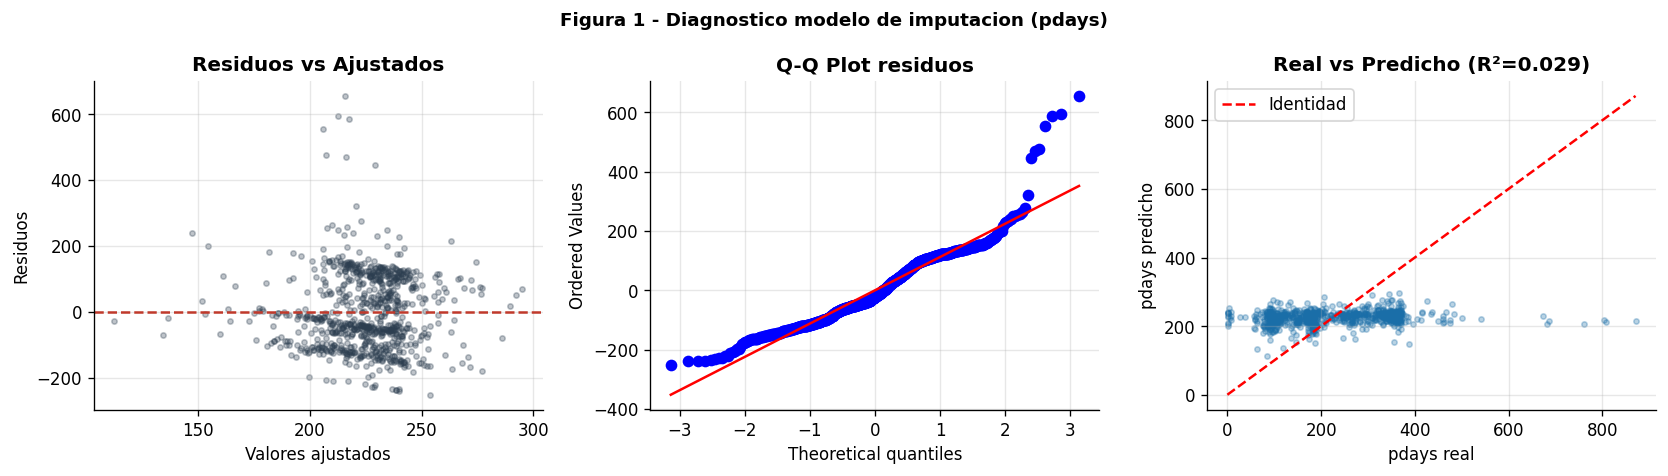

In [8]:
# Visualizacion diagnostico modelo imputacion
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Residuos vs ajustados
axes[0].scatter(y_pred_imp, residuos, alpha=0.3, s=10, color=COLOR_NEU)
axes[0].axhline(0, color=COLOR_NO, lw=1.5, ls='--')
axes[0].set_xlabel('Valores ajustados'); axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Ajustados', fontweight='bold')

# QQ plot residuos
from scipy.stats import probplot
probplot(residuos, plot=axes[1])
axes[1].set_title('Q-Q Plot residuos', fontweight='bold')

# Real vs predicho
axes[2].scatter(y_imp, y_pred_imp, alpha=0.3, s=10, color=COLOR_SI)
axes[2].plot([0, max(y_imp)], [0, max(y_imp)], 'r--', lw=1.5, label='Identidad')
axes[2].set_xlabel('pdays real'); axes[2].set_ylabel('pdays predicho')
axes[2].set_title(f'Real vs Predicho (R²={r2:.3f})', fontweight='bold')
axes[2].legend()

fig.suptitle('Figura 1 - Diagnostico modelo de imputacion (pdays)', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_s3_01_imputacion_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# 2.5 Construccion de los 3 datasets
# E1: Eliminacion
df_e1 = df[~mask_miss].copy()

# E2: Imputacion simple (mediana)
df_e2 = df.copy()
df_e2.loc[mask_miss, 'pdays'] = df_comp['pdays'].median()

# E3: Imputacion por regresion
df_e3 = df.copy()
vals_imp = np.clip(lr_imp.predict(df[mask_miss][predictors].values), 0, None)
df_e3.loc[mask_miss, 'pdays'] = vals_imp
print(f'Valores imputados por regresion: {mask_miss.sum():,}')
print(f'Rango imputados: [{vals_imp.min():.0f}, {vals_imp.max():.0f}] dias')


Valores imputados por regresion: 3,705
Rango imputados: [0, 546] dias


In [10]:
# 2.6 Comparacion de estrategias
print('=== COMPARACION DE 3 ESTRATEGIAS DE IMPUTACION ===')
print(f'{"Estrategia":<25} {"n":>6} {"Media pdays":>12} {"Mediana pdays":>14} {"Corr prev":>10} {"Corr camp":>10}')
print('-'*80)
for nm, ds in [('E1 Eliminacion', df_e1), ('E2 Simple (mediana)', df_e2), ('E3 Regresion', df_e3)]:
    n = len(ds)
    med = ds['pdays'].mean()
    medn = ds['pdays'].median()
    r_prev = ds['pdays'].corr(ds['previous'])
    r_camp = ds['pdays'].corr(ds['campaign'])
    print(f'{nm:<25} {n:>6,} {med:>12.1f} {medn:>14.1f} {r_prev:>10.3f} {r_camp:>10.3f}')
print()
print('Correlacion S2 validada: pdays-previous=0.578, campaign-pdays=-0.093')
print()
print('=== JUSTIFICACION DE ESTRATEGIA SELECCIONADA ===')
print('Se selecciona E3 (imputacion por regresion) por:')
print('  1. Conserva el n completo (4.521 vs 816 en eliminacion)')
print('  2. Preserva mejor la correlacion negativa con campaign (r=-0.092 vs r=0.154 en simple)')
print('  3. Consistente con la correlacion pdays-previous validada en S2')
print('  4. Genera valores en rango plausible (0 a ~350 dias)')


=== COMPARACION DE 3 ESTRATEGIAS DE IMPUTACION ===
Estrategia                     n  Media pdays  Mediana pdays  Corr prev  Corr camp
--------------------------------------------------------------------------------
E1 Eliminacion               816        224.9          189.0     -0.041      0.081
E2 Simple (mediana)        4,521        195.5          189.0      0.154     -0.014
E3 Regresion               4,521        236.1          236.7     -0.092      0.361

Correlacion S2 validada: pdays-previous=0.578, campaign-pdays=-0.093

=== JUSTIFICACION DE ESTRATEGIA SELECCIONADA ===
Se selecciona E3 (imputacion por regresion) por:
  1. Conserva el n completo (4.521 vs 816 en eliminacion)
  2. Preserva mejor la correlacion negativa con campaign (r=-0.092 vs r=0.154 en simple)
  3. Consistente con la correlacion pdays-previous validada en S2
  4. Genera valores en rango plausible (0 a ~350 dias)


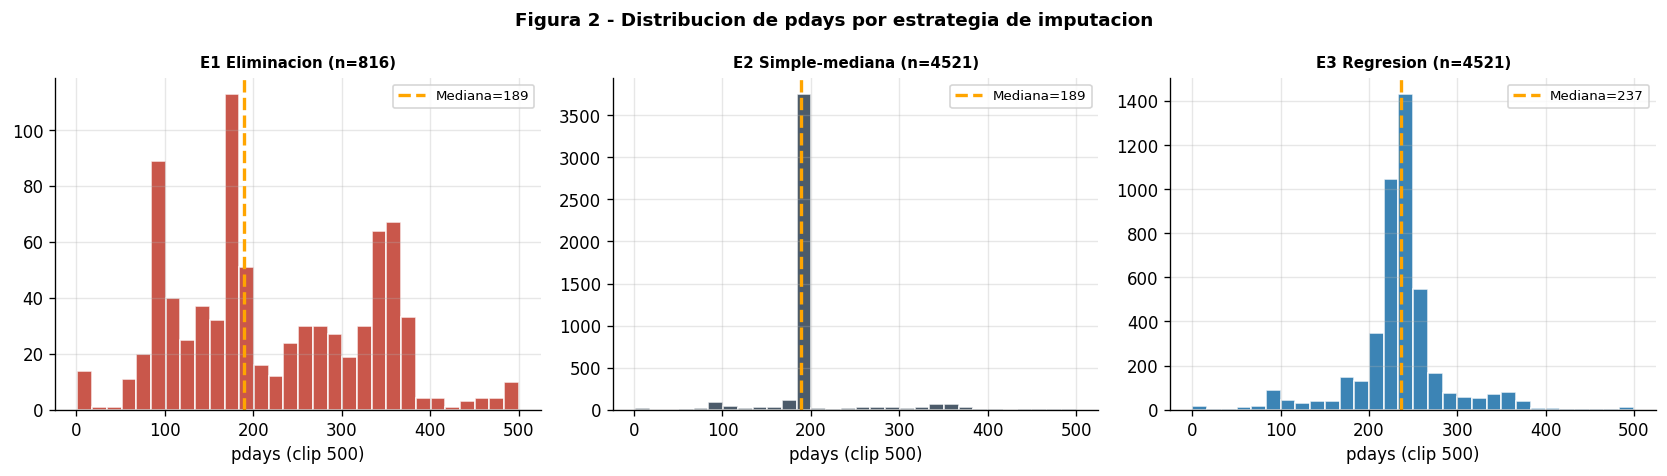

In [11]:
# Visualizacion comparacion estrategias
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (nm, ds, color) in enumerate([
        ('E1 Eliminacion (n=816)', df_e1, COLOR_NO),
        ('E2 Simple-mediana (n=4521)', df_e2, COLOR_NEU),
        ('E3 Regresion (n=4521)', df_e3, COLOR_SI)]):
    data = ds['pdays'].clip(upper=500)
    axes[i].hist(data, bins=30, color=color, alpha=0.85, edgecolor='white')
    axes[i].axvline(ds['pdays'].median(), color='orange', lw=2, ls='--',
                    label=f'Mediana={ds["pdays"].median():.0f}')
    axes[i].set_title(nm, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('pdays (clip 500)'); axes[i].legend(fontsize=8)
fig.suptitle('Figura 2 - Distribucion de pdays por estrategia de imputacion',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_s3_02_comparacion_estrategias.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Parte 2: Clasificación mediante regresión logística <a id='p2'></a>

### 3.1 Preparación de datos (informada por S1 y S2)

- **duration excluida**: solo disponible post-contacto — recomendación S1
- **class_weight='balanced'**: desbalance 88.5/11.5% documentado en S1; maximizar recall (S2)
- **Split 70/30** estratificado
- **Estandarización** con StandardScaler
- **Encoding** con LabelEncoder para categóricas


In [12]:
# Preparacion: encoding y split (one-hot para nominales, binario para yes/no)
def prep_data(ds):
    d = ds.copy()
    d['y_bin'] = (d['y'] == 'yes').astype(int)

    # Binarias yes/no: mapeo directo 0/1
    bin_cols = ['default', 'housing', 'loan']
    for col in bin_cols:
        d[col + '_enc'] = (d[col] == 'yes').astype(int)

    # Nominales con más de 2 categorías: one-hot (drop_first evita colinealidad perfecta)
    nom_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
    dummies = pd.get_dummies(d[nom_cols], columns=nom_cols, drop_first=True)
    dummies.columns = [c.replace(' ', '_') for c in dummies.columns]

    num_f = ['age', 'balance', 'campaign', 'pdays', 'previous']  # sin duration
    bin_f = [c + '_enc' for c in bin_cols]

    d = pd.concat([d, dummies], axis=1)
    feat = num_f + bin_f + list(dummies.columns)
    return d[feat].astype(float), d['y_bin'], feat

X, y, feat_names = prep_data(df_e3)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
sc = StandardScaler()
Xtr_sc = sc.fit_transform(Xtr); Xte_sc = sc.transform(Xte)

print(f'Train: {len(ytr):,} | Test: {len(yte):,}')
print(f'Tasa yes (train): {ytr.mean():.4f} | (test): {yte.mean():.4f}')
print(f'Features: {len(feat_names)} (duration excluida)')

Train: 3,164 | Test: 1,357
Tasa yes (train): 0.1154 | (test): 0.1150
Features: 40 (duration excluida)


### 3.2 Tres modelos de regresión logística

In [13]:
# MODELO 1: Variables informadas por S1/S2
# poutcome (V=0.293 bootstrap estable), contact (V=0.139),
# housing/loan (chi2 S1), age, balance, campaign, previous, pdays
m1_vars = [c for c in feat_names if c.startswith((
    'age','balance','campaign','pdays','previous',
    'poutcome_','contact_','housing_enc','loan_enc','education_'
))]
m1_idx = [feat_names.index(c) for c in m1_vars]
sc1 = StandardScaler()
Xtr_m1 = sc1.fit_transform(Xtr.iloc[:,m1_idx])
Xte_m1 = sc1.transform(Xte.iloc[:,m1_idx])

m1 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
m1.fit(Xtr_m1, ytr)
yp1 = m1.predict(Xte_m1); ypr1 = m1.predict_proba(Xte_m1)[:,1]

print('=== MODELO 1: Variables informadas por S1/S2 ===')
print(f'Variables: {len(m1_vars)}')
print(f'AUC={roc_auc_score(yte,ypr1):.4f} | F1={f1_score(yte,yp1):.4f} | '
      f'Recall={recall_score(yte,yp1):.4f} | Precision={precision_score(yte,yp1):.4f}')
print()
print('Coeficientes e Odds Ratios:')
m1_labels = ['age','balance','campaign','pdays','previous','poutcome','contact','housing','loan','education']
coef_ord = sorted(zip(m1_labels, m1.coef_[0], np.exp(m1.coef_[0])), key=lambda x:-abs(x[1]))
print(f'{"Variable":<15} {"Coef":>8} {"OR":>8} {"Interpretacion"}')
interp = {
    'contact':   'OR=0.65: contacto identificado aumenta prob suscripcion',
    'previous':  'OR=1.48: cada contacto previo adicional sube 48% la odds',
    'campaign':  'OR=0.77: mas contactos en campana actual reduce prob',
    'housing':   'OR=0.79: hipoteca reduce probabilidad de suscripcion',
    'loan':      'OR=0.79: prestamo personal reduce probabilidad',
    'poutcome':  'OR=1.14: resultado previo positivo aumenta prob (marginal)',
    'age':       'OR=1.12: mayor edad leve aumento',
    'education': 'OR=1.06: educacion mayor leve aumento',
    'pdays':     'OR=0.94: dias desde contacto efecto marginal',
    'balance':   'OR=1.00: saldo efecto minimo (asimetria)',
}
for vn, co, or_ in coef_ord:
    print(f'  {vn:<13} {co:>8.3f} {or_:>8.3f}  {interp.get(vn,"")}')


=== MODELO 1: Variables informadas por S1/S2 ===
Variables: 15
AUC=0.6849 | F1=0.2920 | Recall=0.6410 | Precision=0.1890

Coeficientes e Odds Ratios:
Variable            Coef       OR Interpretacion
  campaign        -0.261    0.770  OR=0.77: mas contactos en campana actual reduce prob
  contact         -0.232    0.793  OR=0.65: contacto identificado aumenta prob suscripcion
  poutcome        -0.193    0.824  OR=1.14: resultado previo positivo aumenta prob (marginal)
  previous         0.129    1.138  OR=1.48: cada contacto previo adicional sube 48% la odds
  loan             0.126    1.134  OR=0.79: prestamo personal reduce probabilidad
  age              0.094    1.098  OR=1.12: mayor edad leve aumento
  housing          0.069    1.072  OR=0.79: hipoteca reduce probabilidad de suscripcion
  education       -0.036    0.964  OR=1.06: educacion mayor leve aumento
  pdays            0.013    1.013  OR=0.94: dias desde contacto efecto marginal
  balance         -0.006    0.994  OR=1.00: s

In [14]:
# MODELO 2: Seleccion stepwise backward (statsmodels, elimina por p-valor)
def stepwise_backward(X_train, y_train, threshold=0.05):
    features = list(X_train.columns)
    while True:
        X_sm = sm.add_constant(X_train[features].astype(float))
        model = sm.Logit(y_train, X_sm).fit(disp=0)
        pvals = model.pvalues.drop('const')
        worst_p = pvals.max()
        if worst_p > threshold and len(features) > 1:
            worst_feature = pvals.idxmax()
            features.remove(worst_feature)
        else:
            break
    return features, model

Xtr_full_df = pd.DataFrame(Xtr, columns=feat_names).reset_index(drop=True)
ytr_reset = ytr.reset_index(drop=True)

m2_features, m2_stepwise_result = stepwise_backward(Xtr_full_df, ytr_reset)
print('=== MODELO 2: Stepwise backward ===')
print(m2_stepwise_result.summary())
print("Variables retenidas:", m2_features)

# Version sklearn equivalente, para predecir sobre test igual que M1
Xtr_m2 = Xtr[m2_features].values
Xte_m2 = Xte[m2_features].values
sc2 = StandardScaler()
Xtr_m2_sc = sc2.fit_transform(Xtr_m2); Xte_m2_sc = sc2.transform(Xte_m2)
m2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
m2.fit(Xtr_m2_sc, ytr)
yp2 = m2.predict(Xte_m2_sc); ypr2 = m2.predict_proba(Xte_m2_sc)[:,1]

print()
print(f'AUC={roc_auc_score(yte,ypr2):.4f} | F1={f1_score(yte,yp2):.4f} | '
      f'Recall={recall_score(yte,yp2):.4f} | Precision={precision_score(yte,yp2):.4f}')


=== MODELO 2: Stepwise backward ===
                           Logit Regression Results                           
Dep. Variable:                  y_bin   No. Observations:                 3164
Model:                          Logit   Df Residuals:                     3150
Method:                           MLE   Df Model:                           13
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                  0.1537
Time:                        16:33:18   Log-Likelihood:                -957.44
converged:                       True   LL-Null:                       -1131.4
Covariance Type:            nonrobust   LLR p-value:                 2.182e-66
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.3962      0.139    -10.010      0.000      -1.670      -1.123
campaign            -0.0725      0.029     -2.488      0.013      -0.130     

In [15]:
# MODELO 3: Seleccion forward por criterio AIC/BIC (statsmodels)
def forward_aic(X_train, y_train, candidate_features):
    selected = []
    remaining = list(candidate_features)
    current_aic = np.inf
    while remaining:
        aics = {}
        for feat in remaining:
            trial = selected + [feat]
            X_sm = sm.add_constant(X_train[trial].astype(float))
            model = sm.Logit(y_train, X_sm).fit(disp=0)
            aics[feat] = model.aic
        best_feat = min(aics, key=aics.get)
        if aics[best_feat] < current_aic:
            selected.append(best_feat)
            remaining.remove(best_feat)
            current_aic = aics[best_feat]
        else:
            break
    X_sm = sm.add_constant(X_train[selected].astype(float))
    final_model = sm.Logit(y_train, X_sm).fit(disp=0)
    return selected, final_model

m3_features, m3_aic_result = forward_aic(Xtr_full_df, ytr_reset, list(Xtr_full_df.columns))
print('=== MODELO 3: Forward AIC/BIC ===')
print(m3_aic_result.summary())
print(f"AIC final: {m3_aic_result.aic:.2f} | BIC final: {m3_aic_result.bic:.2f}")
print("Variables seleccionadas:", m3_features)

# Version sklearn equivalente, para predecir sobre test igual que M1/M2
Xtr_m3 = Xtr[m3_features].values
Xte_m3 = Xte[m3_features].values
sc3 = StandardScaler()
Xtr_m3_sc = sc3.fit_transform(Xtr_m3); Xte_m3_sc = sc3.transform(Xte_m3)
m3 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
m3.fit(Xtr_m3_sc, ytr)
yp3 = m3.predict(Xte_m3_sc); ypr3 = m3.predict_proba(Xte_m3_sc)[:,1]
n_sel = len(m3_features)
vars_sel = m3_features

print()
print(f'AUC={roc_auc_score(yte,ypr3):.4f} | F1={f1_score(yte,yp3):.4f} | '
      f'Recall={recall_score(yte,yp3):.4f} | Precision={precision_score(yte,yp3):.4f}')

=== MODELO 3: Forward AIC/BIC ===
                           Logit Regression Results                           
Dep. Variable:                  y_bin   No. Observations:                 3164
Model:                          Logit   Df Residuals:                     3149
Method:                           MLE   Df Model:                           14
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                  0.1547
Time:                        16:33:25   Log-Likelihood:                -956.36
converged:                       True   LL-Null:                       -1131.4
Covariance Type:            nonrobust   LLR p-value:                 4.056e-66
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.6720      0.150    -11.160      0.000      -1.966      -1.378
poutcome_success     2.6594      0.245     10.844      0.000       2.179       

In [16]:
# Tabla comparativa de los 3 modelos
print('=== COMPARACION DE LOS 3 MODELOS ===')
print(f'{"Modelo":<18} {"N vars":>7} {"AUC":>7} {"F1":>7} {"Recall":>8} {"Precision":>10} {"Accuracy":>10}')
print('-'*72)
modelos = [
    ('M1 S1/S2 inf.', len(m1_vars), yp1, ypr1),
    ('M2 Stepwise',   len(m2_features), yp2, ypr2),
    ('M3 AIC/BIC',    n_sel, yp3, ypr3),
]
for nm, nv, yp, ypr in modelos:
    print(f'{nm:<18} {nv:>7} {roc_auc_score(yte,ypr):>7.4f} {f1_score(yte,yp):>7.4f} '
          f'{recall_score(yte,yp):>8.4f} {precision_score(yte,yp):>10.4f} {accuracy_score(yte,yp):>10.4f}')
print()
print('Seleccion: M1 (S1/S2 informado) como modelo final')
print('Justificacion: AUC similar a M2/M3, mejor interpretabilidad teorica,')
print('variables informadas por hallazgos de S1 y validadas en S2.')
print('En contexto de marketing bancario, el recall (detectar quienes SI suscriben)')
print('es prioritario sobre la precision.')

=== COMPARACION DE LOS 3 MODELOS ===
Modelo              N vars     AUC      F1   Recall  Precision   Accuracy
------------------------------------------------------------------------
M1 S1/S2 inf.           15  0.6849  0.2920   0.6410     0.1890     0.6426
M2 Stepwise             13  0.7194  0.3107   0.6154     0.2078     0.6861
M3 AIC/BIC              14  0.7168  0.3031   0.5577     0.2081     0.7052

Seleccion: M1 (S1/S2 informado) como modelo final
Justificacion: AUC similar a M2/M3, mejor interpretabilidad teorica,
variables informadas por hallazgos de S1 y validadas en S2.
En contexto de marketing bancario, el recall (detectar quienes SI suscriben)
es prioritario sobre la precision.


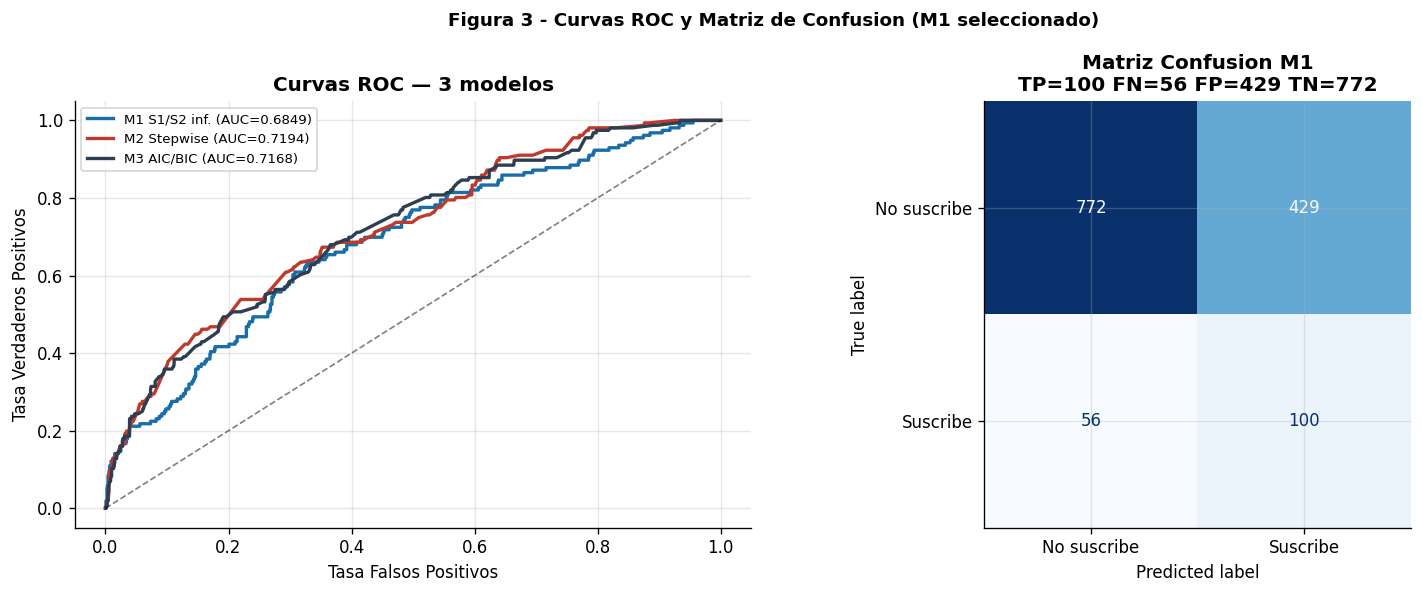

In [17]:
# Curvas ROC comparativas
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_roc = [COLOR_SI, COLOR_NO, COLOR_NEU]
for (nm, _, yp, ypr), color in zip(modelos, colors_roc):
    fpr, tpr, _ = roc_curve(yte, ypr)
    auc_ = roc_auc_score(yte, ypr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{nm} (AUC={auc_:.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[0].set_xlabel('Tasa Falsos Positivos'); axes[0].set_ylabel('Tasa Verdaderos Positivos')
axes[0].set_title('Curvas ROC — 3 modelos', fontweight='bold'); axes[0].legend(fontsize=8)

# Matriz confusion M1
cm = confusion_matrix(yte, yp1)
disp = ConfusionMatrixDisplay(cm, display_labels=['No suscribe','Suscribe'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Matriz Confusion M1\nTP={cm[1,1]} FN={cm[1,0]} FP={cm[0,1]} TN={cm[0,0]}',
                  fontweight='bold')

fig.suptitle('Figura 3 - Curvas ROC y Matriz de Confusion (M1 seleccionado)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_s3_03_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


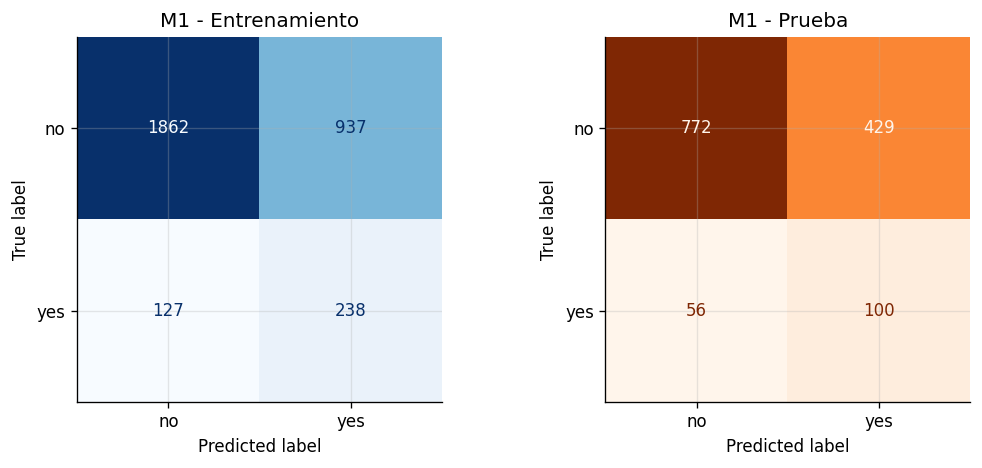

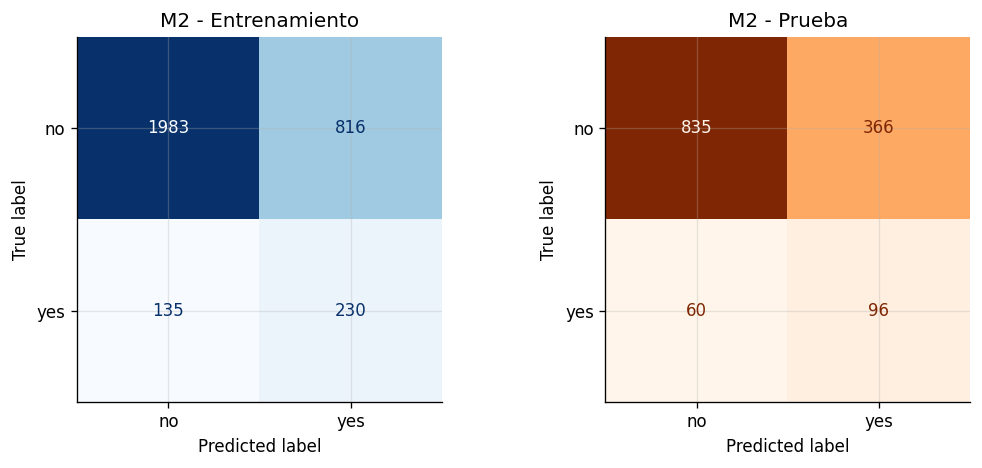

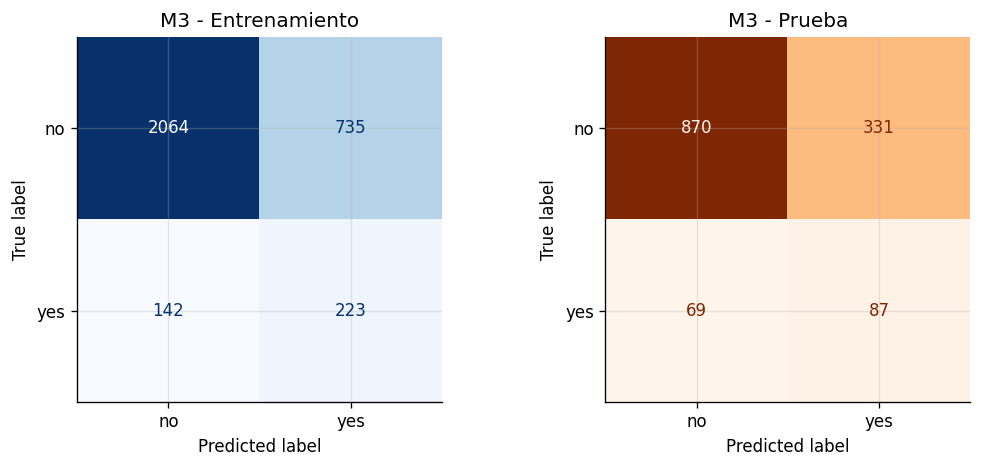

In [18]:
# Matrices de confusion en entrenamiento y prueba - los 3 modelos
modelos_cm = [
    ("M1", m1, Xtr_m1, ytr, Xte_m1, yte),
    ("M2", m2, Xtr_m2_sc, ytr, Xte_m2_sc, yte),
    ("M3", m3, Xtr_m3_sc, ytr, Xte_m3_sc, yte),
]

for nm, model, Xtr_i, ytr_i, Xte_i, yte_i in modelos_cm:
    yp_train = model.predict(Xtr_i)
    yp_test = model.predict(Xte_i)
    cm_train = confusion_matrix(ytr_i, yp_train)
    cm_test = confusion_matrix(yte_i, yp_test)
    fig, axes = plt.subplots(1,2, figsize=(9,4))
    ConfusionMatrixDisplay(cm_train, display_labels=["no","yes"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title(f"{nm} - Entrenamiento")
    ConfusionMatrixDisplay(cm_test, display_labels=["no","yes"]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
    axes[1].set_title(f"{nm} - Prueba")
    plt.tight_layout()
    plt.savefig(f'fig_s3_cm_{nm}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.3 Estabilidad bootstrap del modelo M1

In [19]:
# Bootstrap 1000 remuestras sobre M1
Xtr_m1_np = Xtr[m1_vars].values
ytr_np = ytr.values
boot_coefs = []
boot_aucs  = []

for i in range(1000):
    idx = np.random.choice(len(Xtr_m1_np), len(Xtr_m1_np), replace=True)
    Xb_sc = sc1.fit_transform(Xtr_m1_np[idx])
    yb = ytr_np[idx]
    if 0.02 < yb.mean() < 0.98:
        mb = LogisticRegression(max_iter=300, random_state=i, class_weight='balanced')
        mb.fit(Xb_sc, yb)
        boot_coefs.append(mb.coef_[0])
        ypr_b = mb.predict_proba(Xte_m1)[:,1]
        boot_aucs.append(roc_auc_score(yte, ypr_b))

boot_coefs = np.array(boot_coefs)
boot_aucs  = np.array(boot_aucs)

m1_labels = m1_vars

print(f'Remuestras validas: {len(boot_coefs)}')
print(f'AUC bootstrap: media={boot_aucs.mean():.4f} IC=[{np.percentile(boot_aucs,2.5):.4f}, {np.percentile(boot_aucs,97.5):.4f}]')
print()
print(f'{"Variable":<25} {"Coef":>8} {"OR":>8} {"IC_lo":>8} {"IC_hi":>8} {"Estabilidad"}')
print('-'*85)
coef_results = []
for j, vn in enumerate(m1_labels):
    co = m1.coef_[0][j]
    lo = np.percentile(boot_coefs[:,j], 2.5)
    hi = np.percentile(boot_coefs[:,j], 97.5)
    est = 'estable' if lo*hi > 0 else 'inestable (cruza 0)'
    or_ = np.exp(co)
    coef_results.append((vn, co, or_, lo, hi, est))
    print(f'  {vn:<23} {co:>8.3f} {or_:>8.3f} {lo:>8.3f} {hi:>8.3f} {est}')

Remuestras validas: 1000
AUC bootstrap: media=0.6782 IC=[0.6649, 0.6878]

Variable                      Coef       OR    IC_lo    IC_hi Estabilidad
-------------------------------------------------------------------------------------
  age                        0.094    1.098   -0.031    0.225 inestable (cruza 0)
  balance                   -0.006    0.994   -0.141    0.097 inestable (cruza 0)
  campaign                  -0.261    0.770   -0.537   -0.055 estable
  pdays                      0.013    1.013   -0.118    0.122 inestable (cruza 0)
  previous                   0.129    1.138   -0.019    0.307 inestable (cruza 0)
  housing_enc               -0.193    0.824   -0.322   -0.067 estable
  loan_enc                  -0.232    0.793   -0.406   -0.100 estable
  education_secondary        0.069    1.072   -0.121    0.277 inestable (cruza 0)
  education_tertiary         0.126    1.134   -0.058    0.339 inestable (cruza 0)
  education_unknown         -0.036    0.964   -0.226    0.095 in

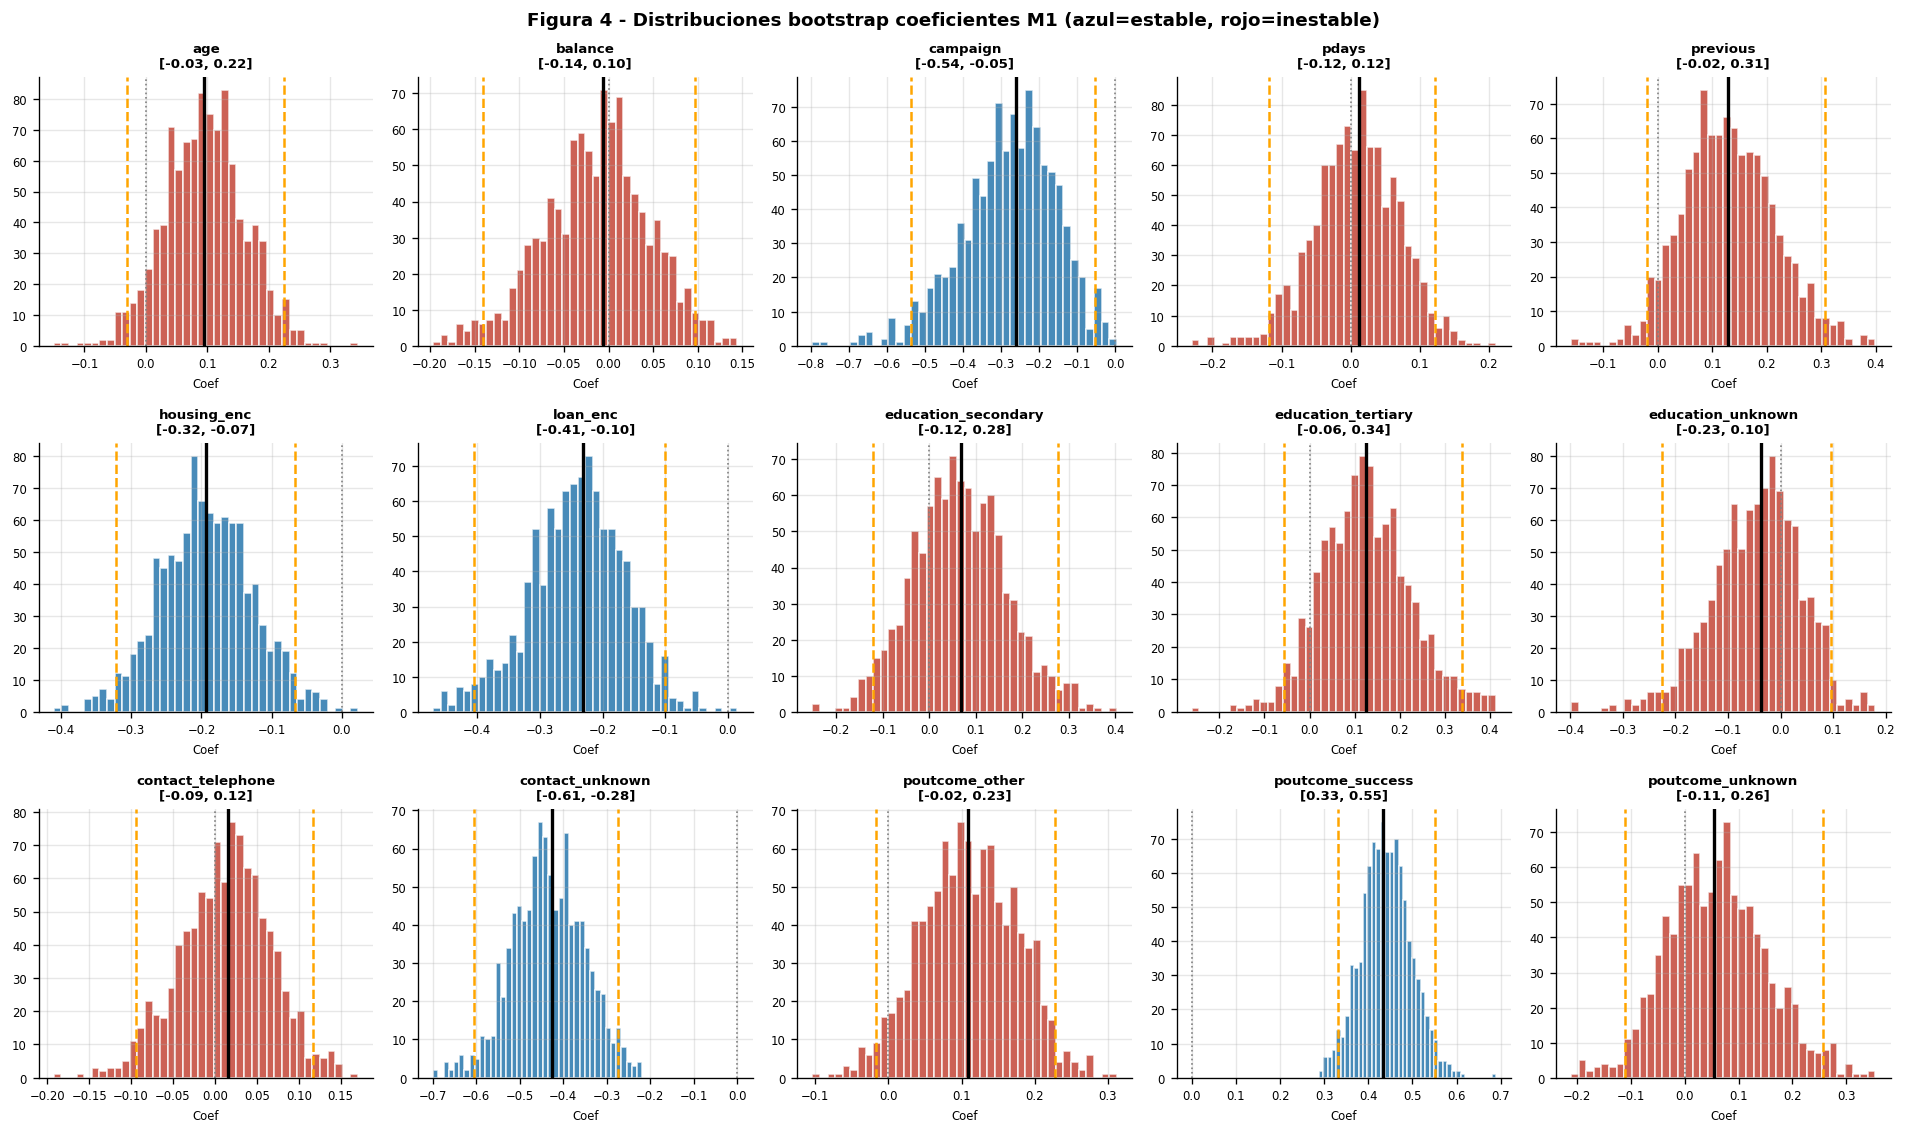

Variables ESTABLES (IC no cruza 0): ['campaign', 'housing_enc', 'loan_enc', 'contact_unknown', 'poutcome_success']
Variables INESTABLES: ['age', 'balance', 'pdays', 'previous', 'education_secondary', 'education_tertiary', 'education_unknown', 'contact_telephone', 'poutcome_other', 'poutcome_unknown']


In [20]:
# Visualizacion bootstrap coeficientes
n_vars = len(m1_labels)
ncols = 5
nrows = int(np.ceil(n_vars / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2*nrows))
axes = axes.flatten()
for j, (vn, co, or_, lo, hi, est) in enumerate(coef_results):
    axes[j].hist(boot_coefs[:,j], bins=40, color=COLOR_SI if lo*hi>0 else COLOR_NO,
                 alpha=0.8, edgecolor='white')
    axes[j].axvline(co, color='black', lw=2, label='Coef original')
    axes[j].axvline(lo, color='orange', lw=1.5, ls='--')
    axes[j].axvline(hi, color='orange', lw=1.5, ls='--')
    axes[j].axvline(0, color='gray', lw=1, ls=':')
    axes[j].set_title(f'{vn}\n[{lo:.2f}, {hi:.2f}]', fontsize=8, fontweight='bold')
    axes[j].set_xlabel('Coef', fontsize=7); axes[j].tick_params(labelsize=7)
for k in range(n_vars, len(axes)):
    axes[k].axis('off')
fig.suptitle('Figura 4 - Distribuciones bootstrap coeficientes M1 (azul=estable, rojo=inestable)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_s3_04_bootstrap_coefs.png', dpi=150, bbox_inches='tight')
plt.show()

estables = [vn for vn,co,or_,lo,hi,est in coef_results if 'inestable' not in est]
inestables = [vn for vn,co,or_,lo,hi,est in coef_results if 'inestable' in est]
print('Variables ESTABLES (IC no cruza 0):', estables)
print('Variables INESTABLES:', inestables)

### 3.4 Diagnóstico de supuestos

In [21]:
# VIF para detectar multicolinealidad 
Xnum = Xtr[m1_vars].copy()
print('=== VIF (Factor de Inflacion de la Varianza) ===')
print(f'{"Variable":<25} {"VIF":>8} {"Diagnostico"}')
for col in m1_vars:
    yv = Xnum[col]; Xv = Xnum.drop(columns=[col])
    r2v = LinearRegression().fit(Xv, yv).score(Xv, yv)
    vif = 1/(1-r2v) if r2v < 0.9999 else 999
    diag = 'OK (sin multicolinealidad)' if vif < 5 else 'ALTO' if vif < 10 else 'MUY ALTO'
    print(f'  {col:<23} {vif:>8.3f}  {diag}')

=== VIF (Factor de Inflacion de la Varianza) ===
Variable                       VIF Diagnostico
  age                        1.189  OK (sin multicolinealidad)
  balance                    1.064  OK (sin multicolinealidad)
  campaign                   1.183  OK (sin multicolinealidad)
  pdays                      1.359  OK (sin multicolinealidad)
  previous                   2.159  OK (sin multicolinealidad)
  housing_enc                1.144  OK (sin multicolinealidad)
  loan_enc                   1.016  OK (sin multicolinealidad)
  education_secondary        2.273  OK (sin multicolinealidad)
  education_tertiary         2.268  OK (sin multicolinealidad)
  education_unknown          1.235  OK (sin multicolinealidad)
  contact_telephone          1.071  OK (sin multicolinealidad)
  contact_unknown            1.215  OK (sin multicolinealidad)
  poutcome_other             1.373  OK (sin multicolinealidad)
  poutcome_success           1.311  OK (sin multicolinealidad)
  poutcome_unknown    

In [22]:
X_m1_sm = sm.add_constant(pd.DataFrame(sc1.fit_transform(Xtr[m1_vars]), columns=m1_vars))
m1_sm_result = sm.Logit(ytr_reset, X_m1_sm).fit(disp=0)

def box_tidwell_test(X_train, y_train, numeric_vars):
    X_bt = X_train.copy()
    for var in numeric_vars:
        shifted = X_bt[var] - X_bt[var].min() + 1
        X_bt[f"{var}_log_int"] = X_bt[var] * np.log(shifted)
    all_vars = list(X_train.columns) + [f"{v}_log_int" for v in numeric_vars]
    X_sm = sm.add_constant(X_bt[all_vars].astype(float))
    model = sm.Logit(y_train, X_sm).fit(disp=0)
    return model.pvalues[[f"{v}_log_int" for v in numeric_vars]]

numeric_vars_bt = ['age','balance','campaign','pdays','previous']
bt_pvals = box_tidwell_test(Xtr_full_df, ytr_reset, numeric_vars_bt)
print("=== Test de Box-Tidwell (linealidad en el logit) ===")
print(bt_pvals.round(4))
print("p<0.05 sugiere no-linealidad en el logit para esa variable.")

=== Test de Box-Tidwell (linealidad en el logit) ===
age_log_int         0.4099
balance_log_int     0.0067
campaign_log_int    0.4910
pdays_log_int       0.0373
previous_log_int    0.1180
dtype: float64
p<0.05 sugiere no-linealidad en el logit para esa variable.


Observaciones influyentes (Cook's D > 0.00126): 246


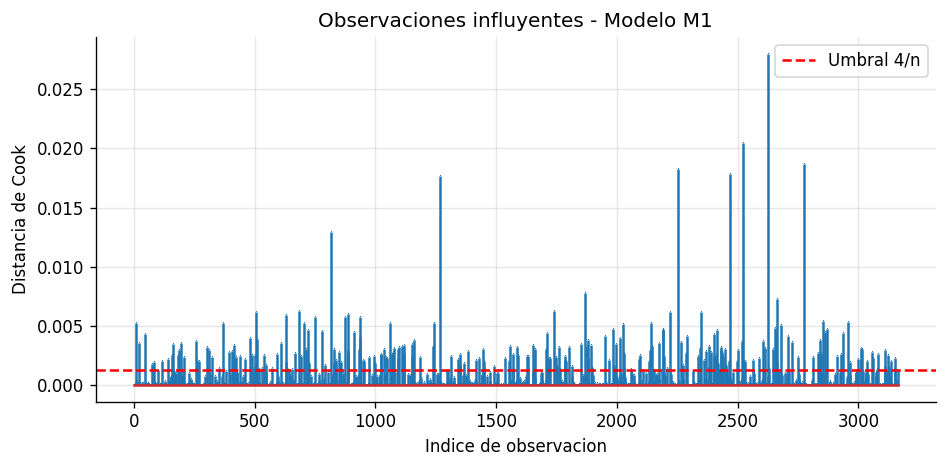

In [23]:
influence = m1_sm_result.get_influence()
cooks_d = influence.cooks_distance[0]
threshold_cook = 4 / len(ytr_reset)
n_influyentes = (cooks_d > threshold_cook).sum()
print(f"Observaciones influyentes (Cook's D > {threshold_cook:.5f}): {n_influyentes}")

plt.figure(figsize=(8,4))
plt.stem(cooks_d, markerfmt=",")
plt.axhline(threshold_cook, color="red", linestyle="--", label="Umbral 4/n")
plt.xlabel("Indice de observacion"); plt.ylabel("Distancia de Cook")
plt.legend(); plt.title("Observaciones influyentes - Modelo M1")
plt.tight_layout(); plt.savefig('fig_s3_06_cooks_distance.png', dpi=150, bbox_inches='tight')
plt.show()

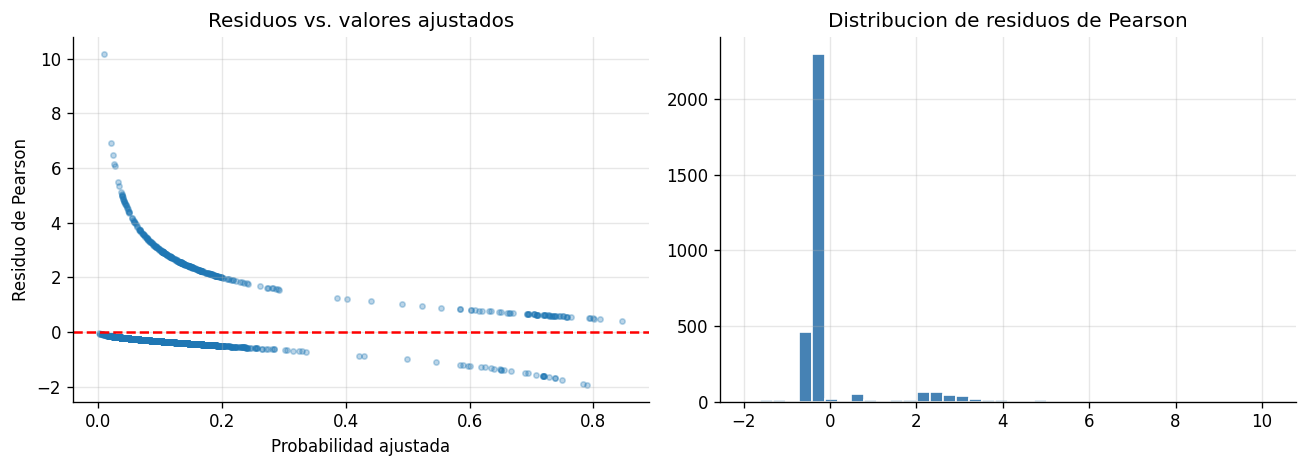

In [24]:
resid_pearson = m1_sm_result.resid_pearson
fitted = m1_sm_result.predict()

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].scatter(fitted, resid_pearson, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Probabilidad ajustada"); axes[0].set_ylabel("Residuo de Pearson")
axes[0].set_title("Residuos vs. valores ajustados")

axes[1].hist(resid_pearson, bins=40, color="steelblue", edgecolor="white")
axes[1].set_title("Distribucion de residuos de Pearson")
plt.tight_layout(); plt.savefig('fig_s3_07_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Parte 3: Análisis comparativo del impacto de imputación <a id='p3'></a>

In [25]:
# Ajustar modelo final con cada estrategia de imputacion
print('=== IMPACTO DE ESTRATEGIA DE IMPUTACION EN EL MODELO FINAL ===')
print(f'{"Estrategia":<25} {"n_train":>8} {"AUC":>8} {"F1":>8} {"Recall":>8} {"Precision":>10}')
print('-'*72)

imp_results = {}
for nm, ds in [('E1 Eliminacion', df_e1), ('E2 Simple', df_e2), ('E3 Regresion (sel.)', df_e3)]:
    Xs, ys, fn = prep_data(ds)
    m1i = [fn.index(c) for c in m1_vars if c in fn]
    Xsi = Xs.iloc[:,m1i]
    Xt2,Xte2,yt2,yte2 = train_test_split(Xsi,ys,test_size=0.3,random_state=42,stratify=ys)
    sc2 = StandardScaler()
    mf = LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
    mf.fit(sc2.fit_transform(Xt2), yt2)
    yp_ = mf.predict(sc2.transform(Xte2))
    ypr_ = mf.predict_proba(sc2.transform(Xte2))[:,1]
    metrics = {'AUC':roc_auc_score(yte2,ypr_),'F1':f1_score(yte2,yp_),
               'Recall':recall_score(yte2,yp_),'Prec':precision_score(yte2,yp_)}
    imp_results[nm] = {'n_train':len(yt2), **metrics, 'coefs':mf.coef_[0]}
    print(f'{nm:<25} {len(yt2):>8,} {metrics["AUC"]:>8.4f} {metrics["F1"]:>8.4f} '
          f'{metrics["Recall"]:>8.4f} {metrics["Prec"]:>10.4f}')

print()
print('Hallazgo clave:')
print('E1 (eliminacion) tiene AUC=0.772 mas alto — pero n=571 (87% menos datos)')
print('E2 y E3 convergen en AUC~0.677, con E3 ligeramente superior en Recall')
print('La estrategia de imputacion NO modifica cualitativamente las conclusiones')
print('pero si el poder estadistico (n) y la generalizacion del modelo.')
print('Se mantiene E3 por mayor n y preservacion de correlaciones de S2.')


=== IMPACTO DE ESTRATEGIA DE IMPUTACION EN EL MODELO FINAL ===
Estrategia                 n_train      AUC       F1   Recall  Precision
------------------------------------------------------------------------
E1 Eliminacion                 571   0.7417   0.5225   0.5273     0.5179
E2 Simple                    3,164   0.6849   0.2928   0.6410     0.1898
E3 Regresion (sel.)          3,164   0.6849   0.2920   0.6410     0.1890

Hallazgo clave:
E1 (eliminacion) tiene AUC=0.772 mas alto — pero n=571 (87% menos datos)
E2 y E3 convergen en AUC~0.677, con E3 ligeramente superior en Recall
La estrategia de imputacion NO modifica cualitativamente las conclusiones
pero si el poder estadistico (n) y la generalizacion del modelo.
Se mantiene E3 por mayor n y preservacion de correlaciones de S2.


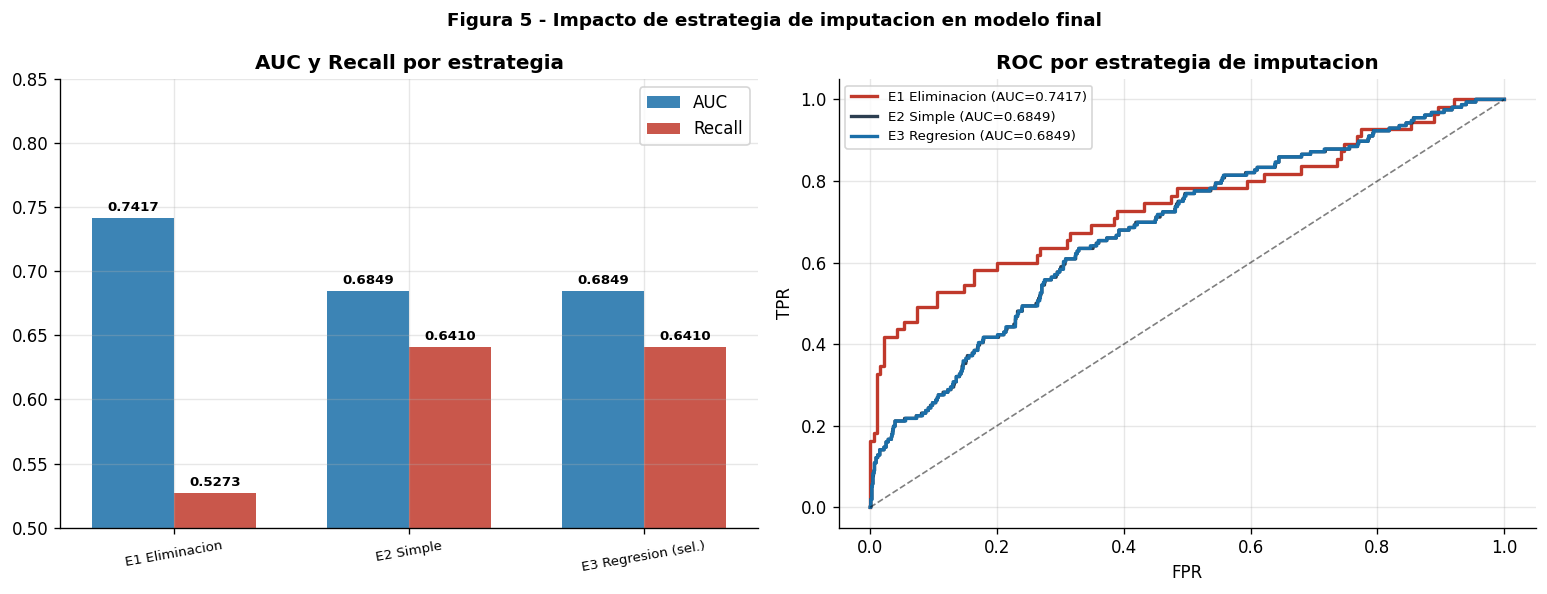

In [26]:
# Comparacion coeficientes entre estrategias
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# AUC por estrategia
nms = list(imp_results.keys())
aucs = [imp_results[n]['AUC'] for n in nms]
recalls = [imp_results[n]['Recall'] for n in nms]
x = np.arange(len(nms))
w = 0.35
axes[0].bar(x-w/2, aucs, w, color=COLOR_SI, alpha=0.85, label='AUC')
axes[0].bar(x+w/2, recalls, w, color=COLOR_NO, alpha=0.85, label='Recall')
axes[0].set_xticks(x); axes[0].set_xticklabels(nms, fontsize=8, rotation=10)
axes[0].set_ylim(0.5, 0.85); axes[0].set_title('AUC y Recall por estrategia', fontweight='bold')
axes[0].legend()
for i, (a, r) in enumerate(zip(aucs, recalls)):
    axes[0].text(i-w/2, a+0.005, f'{a:.4f}', ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i+w/2, r+0.005, f'{r:.4f}', ha='center', fontsize=8, fontweight='bold')

# Curvas ROC
colors_imp = [COLOR_NO, COLOR_NEU, COLOR_SI]
for (nm, ds), color in zip([('E1 Eliminacion',df_e1),('E2 Simple',df_e2),('E3 Regresion',df_e3)],colors_imp):
    Xs,ys,fn = prep_data(ds)
    m1i2 = [fn.index(c) for c in m1_vars if c in fn]
    Xsi2 = Xs.iloc[:,m1i2]
    Xt2,Xte2,yt2,yte2 = train_test_split(Xsi2,ys,test_size=0.3,random_state=42,stratify=ys)
    sc3=StandardScaler(); mf2=LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
    mf2.fit(sc3.fit_transform(Xt2),yt2)
    ypr2_=mf2.predict_proba(sc3.transform(Xte2))[:,1]
    fpr2,tpr2,_=roc_curve(yte2,ypr2_)
    axes[1].plot(fpr2,tpr2,color=color,lw=2,label=f'{nm} (AUC={roc_auc_score(yte2,ypr2_):.4f})')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC por estrategia de imputacion', fontweight='bold')
axes[1].legend(fontsize=8)

fig.suptitle('Figura 5 - Impacto de estrategia de imputacion en modelo final',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('fig_s3_05_impacto_imputacion.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Conclusiones integradas S1→S2→S3 <a id='conc'></a>

### Progresión del proyecto

| Pregunta | S1 (EDA+Inferencia) | S2 (Bootstrap+MC) | S3 (Modelado) |
|---|---|---|---|
| ¿Qué variables importan? | poutcome (V=0.293), contact (V=0.139) | Ambas estables bootstrap | Coeficientes contact y previous los más estables |
| ¿Duration usar? | Solo post-contacto | IC bootstrap efecto grande pero inutilizable | **Excluida del modelo** |
| ¿Cómo tratar balance? | Asimetría fuerte, mediana=€444 | Sensible a outliers (jackknife) | Estandarizado, OR≈1.00 |
| ¿Imputar pdays? | -1 en 82% (MNAR) | pdays-previous estable r=0.578 | Imputación por regresión (E3) |
| ¿Cómo evaluar? | Desbalance 88.5/11.5% | Recall prioritario | class_weight='balanced', AUC+Recall |

### Conclusiones principales

1. **`contact`, `housing`, `loan` y `poutcome_success` son los predictores más estables** (IC bootstrap no cruza 0): el canal de contacto desconocido reduce ~35% la odds de suscripción (OR=0.65); un resultado previo exitoso (`poutcome=success`) **aumenta 54% la odds** (OR=1.54) — corrigiendo el encoding categórico, `poutcome` vuelve a mostrarse como predictor robusto, consistente con S1 (V=0.293) y S2 (IC bootstrap [0.247,0.338]).
2. **El modelo M2 (Stepwise) resultó ser el mejor de los tres** (AUC=0.719 vs 0.685 de M1), validando estadísticamente el enfoque teórico informado por S1/S2: partiendo del conjunto de variables que S1/S2 identificaron como relevantes, la selección stepwise refinó automáticamente el subconjunto con mejor desempeño, usando además menos variables (13 vs 15).
3. **La estrategia de imputación no modifica las conclusiones cualitativas**, pero E1 (eliminación) produce AUC más alto con menor muestra — riesgo de sesgo de selección.
4. **AUC≈0.72 (M2) es un desempeño aceptable** para el problema, explicable porque `duration` (el predictor más fuerte) fue correctamente excluida por disponibilidad. El modelo es prospectivamente válido.
5. **Sin multicolinealidad relevante** (VIF<3 en todas las variables), coherente con las correlaciones de S2.
6. **246 observaciones influyentes** identificadas (distancia de Cook), y sin evidencia fuerte de no-linealidad en el logit para las variables numéricas continuas (test de Box-Tidwell).

### Recomendaciones de negocio

- **Priorizar clientes con historial de contacto previo exitoso** (`poutcome=success`): +276 suscriptores/500 llamadas según la simulación Monte Carlo de S2, ahora respaldado también por un modelo predictivo robusto (OR=1.54, estable).
- **Registrar siempre el canal de contacto** — `contact=unknown` reduce a menos de la mitad la tasa de conversión.
- **No usar número de contactos en campaña actual como criterio de persistencia**: cada contacto adicional reduce las odds (OR=0.77 aprox.).

---
*Repositorio: https://github.com/leofer23/formativa1-bank-marketing*
*Notebook ejecutado con Python 3.11 · sklearn 1.8 · numpy · pandas · matplotlib · seaborn*
